# Deep Residual Learning from Scratch: ResNet on CIFAR-10

This notebook is a complete learning project inspired by the paper:

**Deep Residual Learning for Image Recognition**  
Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun

The goal is not only to train a model, but to understand the theory behind residual learning and apply modern deep learning practices in a clean, GitHub-ready project.

---

## What we will learn

By completing this notebook, you will learn:

1. What the degradation problem is in deep plain neural networks.
2. Why residual learning helps very deep networks train better.
3. How identity shortcuts and projection shortcuts work.
4. How to build a plain CNN baseline.
5. How to build a ResNet-style CNN from scratch.
6. How to train on CIFAR-10 using modern techniques.
7. How to compare a plain CNN and a residual CNN.
8. How to evaluate model performance with metrics, plots, and error analysis.
9. How to organize this as a strong GitHub portfolio project.

---

## Main idea

A normal deep network tries to learn:

```text
H(x)
```

A residual network learns:

```text
F(x) = H(x) - x
```

Then the final output becomes:

```text
H(x) = F(x) + x
```

This simple shortcut connection makes very deep networks easier to optimize.

# Background: Why ResNet Was Important

Before ResNet, researchers already knew that deeper neural networks could learn better representations. However, simply adding more layers did not always improve performance.

The ResNet paper introduced a key problem called the **degradation problem**.

## Degradation problem

Degradation means that when a plain neural network becomes deeper, its training error becomes worse instead of better.

This is surprising because a deeper model should theoretically be able to perform at least as well as a shallower one. The extra layers could simply learn identity mappings and preserve the previous solution.

But in practice, deep plain networks are difficult to optimize.

## Degradation is not the same as vanishing gradients

Vanishing gradients happen when gradients become extremely small during backpropagation.

The ResNet paper argues that degradation is different because modern techniques such as:

- better initialization
- batch normalization
- stochastic gradient descent

allow deep networks to start converging. Even then, deeper plain networks can still have worse training error.

## Degradation is not the same as overfitting

Overfitting means:

```text
training error is low, but validation/test error is high
```

Degradation means:

```text
training error itself becomes higher
```

So the deeper model is not just failing to generalize. It is failing to optimize well.

# Core Theory: Residual Learning

Suppose a block of layers receives input `x`.

A plain network tries to directly learn a mapping:

```text
H(x)
```

A residual network instead learns:

```text
F(x) = H(x) - x
```

Then the block output is:

```text
F(x) + x
```

The shortcut path passes `x` forward directly.

---

## Why this helps

If the best function is close to identity, then a plain network must learn:

```text
H(x) ≈ x
```

That can be difficult for several nonlinear layers.

A residual network only needs to learn:

```text
F(x) ≈ 0
```

This is often easier.

---

## Residual block structure

A basic residual block has two paths:

### Main path

```text
x → Conv → BatchNorm → ReLU → Conv → BatchNorm → F(x)
```

### Shortcut path

```text
x → identity or projection shortcut
```

### Output

```text
output = F(x) + shortcut(x)
```

Then a ReLU activation is applied.

# Identity Shortcut vs Projection Shortcut

Residual addition requires both tensors to have the same shape.

## Case 1: Same shape

If input and output have the same number of channels and the same spatial size, use an identity shortcut:

```python
shortcut = nn.Identity()
```

Example:

```text
Input:  [batch, 64, 32, 32]
Output: [batch, 64, 32, 32]
```

## Case 2: Different shape

If the number of channels changes or the spatial size changes, use a projection shortcut.

Example:

```text
Input:  [batch, 64, 32, 32]
Output: [batch, 128, 16, 16]
```

Use a `1x1` convolution with stride 2:

```python
shortcut = nn.Sequential(
    nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
    nn.BatchNorm2d(128)
)
```

This is called a **projection shortcut**.

---

## Practical rule

Use:

```text
identity shortcut → when shapes match
projection shortcut → when shapes do not match
```

# Project Plan

In this notebook, we will build and compare two models.

## Model A: Plain CNN

A normal convolutional neural network without residual connections.

Purpose:

- works as a baseline
- shows normal CNN training behavior
- helps us compare against ResNet

## Model B: ResNet-style CNN

A convolutional neural network using residual blocks.

Purpose:

- applies the main idea from the ResNet paper
- trains deeper blocks more effectively
- usually gives better optimization and accuracy

---

## Dataset

We will use **CIFAR-10**.

CIFAR-10 contains:

- 60,000 color images
- 32×32 pixels
- 10 classes
- 50,000 training images
- 10,000 test images

Classes:

```text
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
```

---

## Modern techniques used in this notebook

We will go beyond a basic implementation by using:

1. Data augmentation
2. Batch normalization
3. Label smoothing
4. SGD with momentum
5. Cosine learning rate scheduling
6. Automatic mixed precision training
7. Gradient clipping
8. Model checkpointing
9. Confusion matrix
10. Error analysis
11. Training curves
12. Parameter counting
13. Reproducibility seed

# Install and Import Libraries

Run the next cell first.

If you are using Google Colab, Kaggle, or a local environment with PyTorch installed, this should work directly.

If `torchinfo` is missing, install it with:

```bash
pip install torchinfo
```

In [1]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split
from tqdm.auto import tqdm

try:
    from torchinfo import summary
    TORCHINFO_AVAILABLE = True
except Exception:
    TORCHINFO_AVAILABLE = False

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
CUDA available: False


# Reproducibility Setup

Machine learning training is partly random.

We set a seed to make results more reproducible.

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # These settings make experiments more reproducible.
    # They may slightly reduce speed.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Configuration

This cell controls the main hyperparameters.

For a quick test, set `num_epochs = 5`.

For better results, use `num_epochs = 50` or more.

In [3]:
config = {
    "batch_size": 128,
    "num_epochs": 5,
    "learning_rate": 0.1,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "label_smoothing": 0.1,
    "num_workers": 2,
    "use_amp": True,
    "grad_clip": 1.0,
    "seed": 42,
    "val_split": 5000,
    "checkpoint_dir": "checkpoints",
    "results_dir": "results"
}

Path(config["checkpoint_dir"]).mkdir(exist_ok=True)
Path(config["results_dir"]).mkdir(exist_ok=True)

config

{'batch_size': 128,
 'num_epochs': 5,
 'learning_rate': 0.1,
 'momentum': 0.9,
 'weight_decay': 0.0005,
 'label_smoothing': 0.1,
 'num_workers': 2,
 'use_amp': True,
 'grad_clip': 1.0,
 'seed': 42,
 'val_split': 5000,
 'checkpoint_dir': 'checkpoints',
 'results_dir': 'results'}

# Load CIFAR-10 Dataset

We use data augmentation for training.

## Training augmentations

- Random crop
- Random horizontal flip
- AutoAugment for CIFAR-10
- Normalization

## Test transforms

For validation and test data, we only apply:

- conversion to tensor
- normalization

In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# Create train and validation split
val_size = config["val_split"]
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(config["seed"])
)

# Important:
# val_dataset currently uses train_transform because it is a subset of full_train_dataset.
# For stricter validation, we create a separate validation dataset with test_transform.
base_train_for_val = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=test_transform
)

val_indices = val_dataset.indices
val_dataset = torch.utils.data.Subset(base_train_for_val, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=config["num_workers"],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=True
)

class_names = full_train_dataset.classes
print(class_names)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 170M/170M [00:02<00:00, 67.4MB/s] 


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 45000
Validation size: 5000
Test size: 10000


# Visualize Sample Images

Because images are normalized, we define an `unnormalize` function before plotting.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


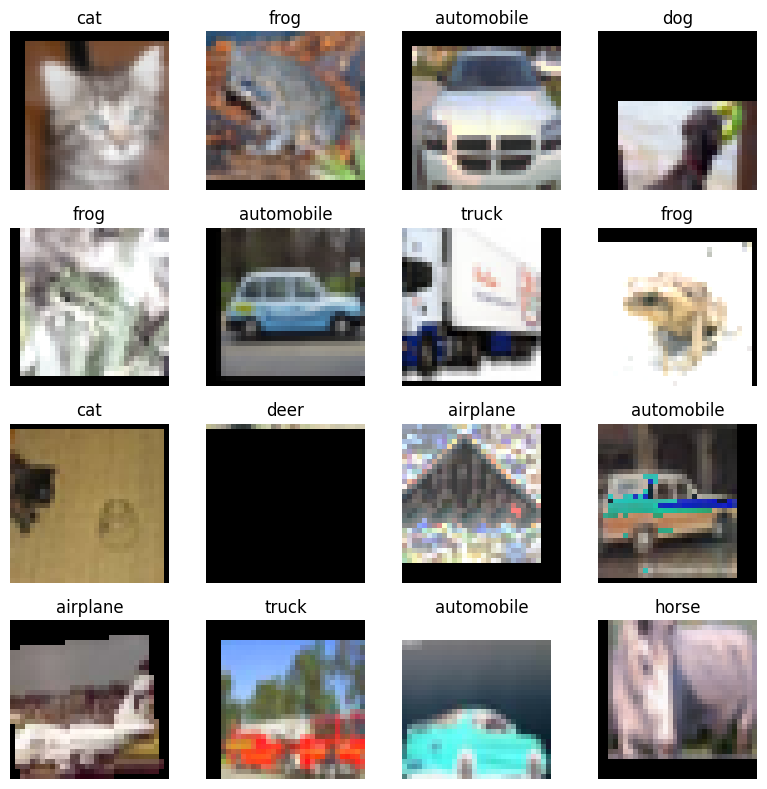

In [5]:
def unnormalize(img_tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    img = img_tensor.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return torch.clamp(img, 0, 1)

def show_batch(loader, class_names, n=16):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]

    rows = int(np.sqrt(n))
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        img = unnormalize(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, class_names, n=16)

# Helper Functions

We define reusable utility functions for:

- accuracy calculation
- parameter counting
- training history storage
- plotting curves

In [6]:
def accuracy_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct, total

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

def plot_history(history, title="Training History"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# Model A: Plain CNN Baseline

This model does not use residual connections.

It is useful because we need a baseline to compare with the ResNet model.

In [7]:
class PlainCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.1):
        super().__init__()

        self.features = nn.Sequential(
            # Stage 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Stage 2
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # Stage 3
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.dropout = nn.Dropout(dropout)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# Model B: Residual Block

This is the most important part of the notebook.

The residual block implements:

```text
output = F(x) + shortcut(x)
```

Where:

- `F(x)` is the main convolution path
- `shortcut(x)` is either identity or projection

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        # Projection shortcut if shape changes
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))

        out = out + identity
        out = F.relu(out)

        return out

# Build a ResNet-style CNN for CIFAR-10

This model has:

- a stem convolution
- three stages of residual blocks
- global average pooling
- final classifier

The model is smaller than the original ImageNet ResNet, but it uses the same core idea.

In [9]:
class ResNetCIFAR10(nn.Module):
    def __init__(self, num_classes=10, blocks_per_stage=(2, 2, 2), dropout=0.1):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.stage1 = self._make_stage(
            in_channels=64,
            out_channels=64,
            num_blocks=blocks_per_stage[0],
            first_stride=1,
            dropout=dropout
        )

        self.stage2 = self._make_stage(
            in_channels=64,
            out_channels=128,
            num_blocks=blocks_per_stage[1],
            first_stride=2,
            dropout=dropout
        )

        self.stage3 = self._make_stage(
            in_channels=128,
            out_channels=256,
            num_blocks=blocks_per_stage[2],
            first_stride=2,
            dropout=dropout
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(256, num_classes)

    def _make_stage(self, in_channels, out_channels, num_blocks, first_stride, dropout):
        layers = []

        layers.append(
            ResidualBlock(
                in_channels,
                out_channels,
                stride=first_stride,
                dropout=dropout
            )
        )

        for _ in range(1, num_blocks):
            layers.append(
                ResidualBlock(
                    out_channels,
                    out_channels,
                    stride=1,
                    dropout=dropout
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Check Model Shapes and Parameter Counts

Before training, always check:

- model output shape
- number of trainable parameters
- model summary

In [10]:
plain_model = PlainCNN(num_classes=10).to(device)
resnet_model = ResNetCIFAR10(num_classes=10, blocks_per_stage=(2, 2, 2), dropout=0.1).to(device)

dummy_input = torch.randn(4, 3, 32, 32).to(device)

with torch.no_grad():
    plain_output = plain_model(dummy_input)
    resnet_output = resnet_model(dummy_input)

print("Plain CNN output shape:", plain_output.shape)
print("ResNet output shape:", resnet_output.shape)

print("Plain CNN parameters:", count_parameters(plain_model))
print("ResNet parameters:", count_parameters(resnet_model))

if TORCHINFO_AVAILABLE:
    summary(resnet_model, input_size=(1, 3, 32, 32))
else:
    print("Install torchinfo to see model summary: pip install torchinfo")

Plain CNN output shape: torch.Size([4, 10])
ResNet output shape: torch.Size([4, 10])
Plain CNN parameters: 1148874
ResNet parameters: 2777674
Install torchinfo to see model summary: pip install torchinfo


# Training and Evaluation Functions

This training loop uses modern techniques:

## Mixed precision training

Mixed precision can speed up training on GPU and reduce memory usage.

## Gradient clipping

Gradient clipping can improve stability by preventing very large gradient updates.

## Cosine learning rate scheduler

Cosine scheduling gradually decreases the learning rate in a smooth curve.

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None, grad_clip=None):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        use_amp = scaler is not None and device.type == "cuda"

        if use_amp:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()

            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            scaler.step(optimizer)
            scaler.update()

        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

        running_loss += loss.item()
        batch_correct, batch_total = accuracy_from_logits(outputs, labels)
        correct += batch_correct
        total += batch_total

        progress_bar.set_postfix({
            "loss": running_loss / max(1, len(progress_bar)),
            "acc": 100 * correct / total
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Evaluating", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        batch_correct, batch_total = accuracy_from_logits(outputs, labels)
        correct += batch_correct
        total += batch_total

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

# Full Training Function

This function trains a model and saves the best checkpoint based on validation accuracy.

In [12]:
def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    config,
    device
):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(
        label_smoothing=config["label_smoothing"]
    )

    optimizer = optim.SGD(
        model.parameters(),
        lr=config["learning_rate"],
        momentum=config["momentum"],
        weight_decay=config["weight_decay"],
        nesterov=True
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config["num_epochs"]
    )

    scaler = torch.cuda.amp.GradScaler() if (config["use_amp"] and device.type == "cuda") else None

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }

    best_val_acc = 0.0
    best_path = Path(config["checkpoint_dir"]) / f"best_{model_name}.pth"

    start_time = time.time()

    for epoch in range(config["num_epochs"]):
        current_lr = get_lr(optimizer)

        print(f"\nEpoch [{epoch + 1}/{config['num_epochs']}] | LR: {current_lr:.6f}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            scaler=scaler,
            grad_clip=config["grad_clip"]
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch + 1,
                "best_val_acc": best_val_acc,
                "config": config
            }, best_path)
            print(f"Saved best checkpoint: {best_path}")

    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time / 60:.2f} minutes.")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")

    history_path = Path(config["results_dir"]) / f"{model_name}_history.csv"
    pd.DataFrame(history).to_csv(history_path, index=False)
    print(f"Saved history to: {history_path}")

    return model, history, best_path

# Train the Plain CNN Baseline

This gives us a baseline result.

For faster testing, you can temporarily reduce `config["num_epochs"]`.


Epoch [1/5] | LR: 0.100000


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 1.8389 | Train Acc: 37.56% | Val Loss: 1.4756 | Val Acc: 54.00%
Saved best checkpoint: checkpoints/best_plain_cnn.pth

Epoch [2/5] | LR: 0.090451


Training:   0%|          | 0/352 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a3b7b34a660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7a3b7b34a660>self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()if w.is_alive():

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive():
        ^ ^ ^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/lib/python

Train Loss: 1.2699 | Train Acc: 67.08% | Val Loss: 1.1267 | Val Acc: 73.36%
Saved best checkpoint: checkpoints/best_plain_cnn.pth

Epoch [5/5] | LR: 0.009549


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 1.1929 | Train Acc: 70.95% | Val Loss: 1.0519 | Val Acc: 77.66%
Saved best checkpoint: checkpoints/best_plain_cnn.pth

Training completed in 98.25 minutes.
Best validation accuracy: 77.66%
Saved history to: results/plain_cnn_history.csv


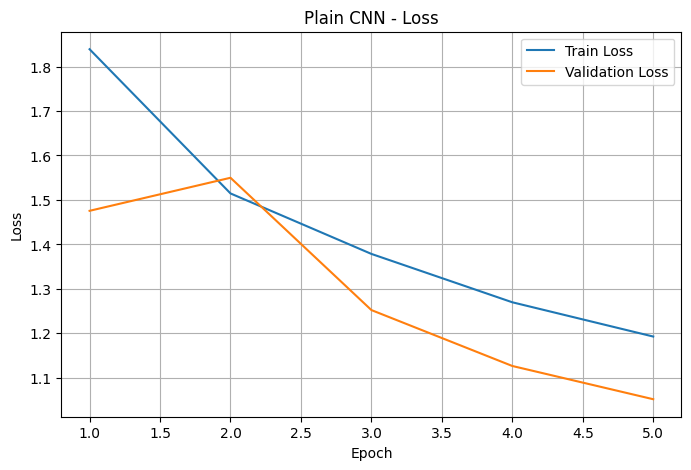

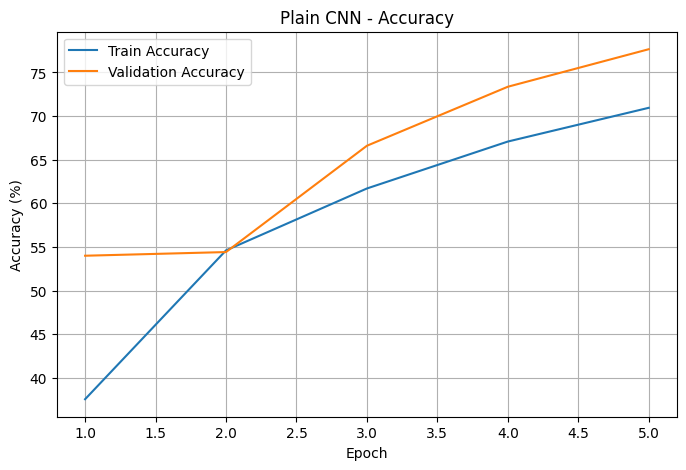

In [13]:
plain_model = PlainCNN(num_classes=10, dropout=0.1)

plain_model, plain_history, plain_best_path = train_model(
    model=plain_model,
    model_name="plain_cnn",
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    device=device
)

plot_history(plain_history, title="Plain CNN")

# Train the ResNet Model

Now we train the residual network.

This is the main model of the project.


Epoch [1/5] | LR: 0.100000


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 1.9213 | Train Acc: 33.40% | Val Loss: 1.7051 | Val Acc: 47.54%
Saved best checkpoint: checkpoints/best_resnet_cifar10.pth

Epoch [2/5] | LR: 0.090451


Training:   0%|          | 0/352 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 1.2696 | Train Acc: 66.47% | Val Loss: 1.0619 | Val Acc: 75.80%
Saved best checkpoint: checkpoints/best_resnet_cifar10.pth

Epoch [5/5] | LR: 0.009549


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 1.1769 | Train Acc: 70.95% | Val Loss: 1.0017 | Val Acc: 78.74%
Saved best checkpoint: checkpoints/best_resnet_cifar10.pth

Training completed in 250.80 minutes.
Best validation accuracy: 78.74%
Saved history to: results/resnet_cifar10_history.csv


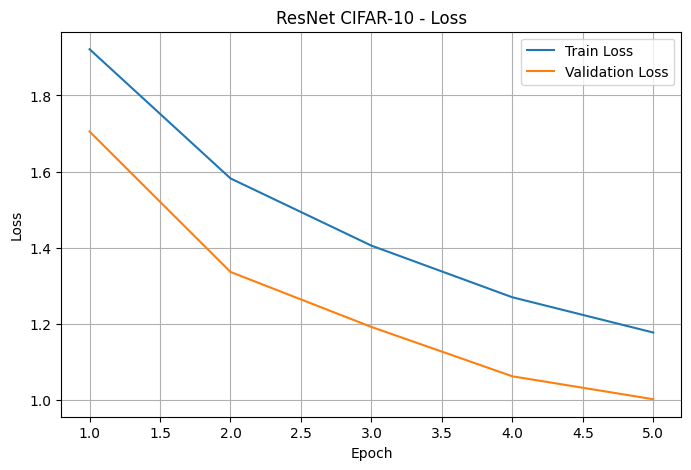

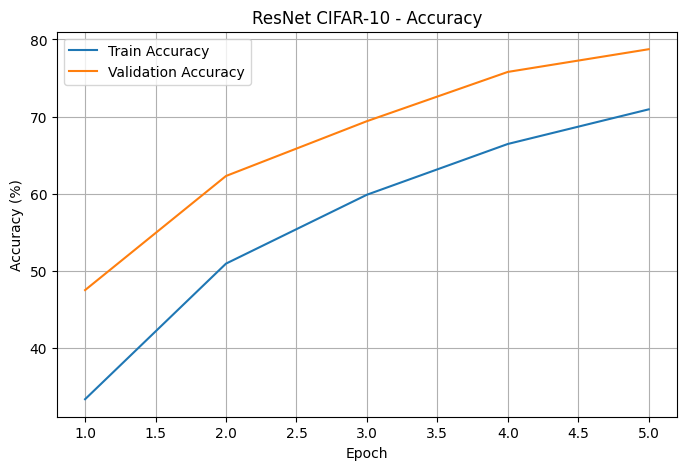

In [14]:
resnet_model = ResNetCIFAR10(
    num_classes=10,
    blocks_per_stage=(2, 2, 2),
    dropout=0.1
)

resnet_model, resnet_history, resnet_best_path = train_model(
    model=resnet_model,
    model_name="resnet_cifar10",
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    device=device
)

plot_history(resnet_history, title="ResNet CIFAR-10")

# Compare Plain CNN vs ResNet

This comparison is the most important result of the notebook.

We compare:

- training loss
- validation loss
- training accuracy
- validation accuracy

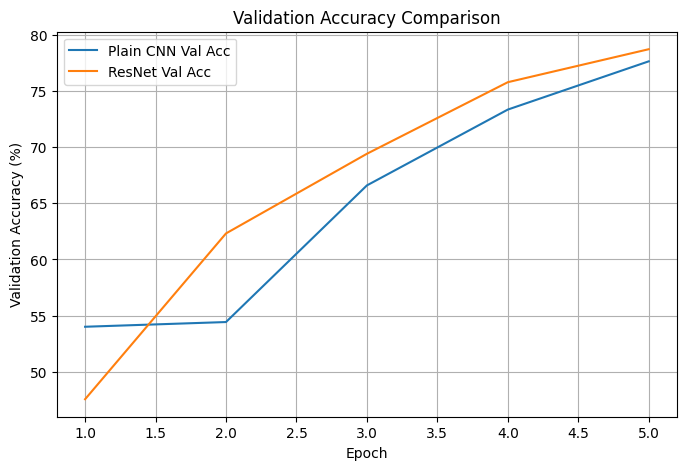

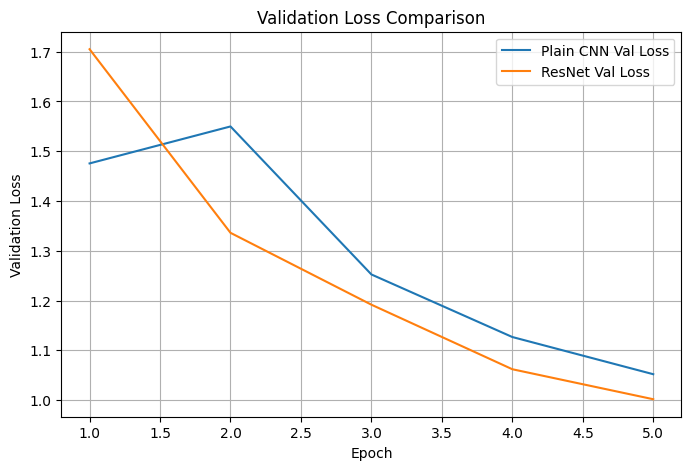

,Model,Parameters,Best Validation Accuracy,Final Validation Accuracy
0,Plain CNN,1148874,77.66,77.66
1,ResNet,2777674,78.74,78.74


In [15]:
def compare_histories(histories, labels):
    epochs = range(1, len(histories[0]["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    for history, label in zip(histories, labels):
        plt.plot(epochs, history["val_acc"], label=f"{label} Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    for history, label in zip(histories, labels):
        plt.plot(epochs, history["val_loss"], label=f"{label} Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

compare_histories(
    histories=[plain_history, resnet_history],
    labels=["Plain CNN", "ResNet"]
)

summary_df = pd.DataFrame({
    "Model": ["Plain CNN", "ResNet"],
    "Parameters": [count_parameters(plain_model), count_parameters(resnet_model)],
    "Best Validation Accuracy": [
        max(plain_history["val_acc"]),
        max(resnet_history["val_acc"])
    ],
    "Final Validation Accuracy": [
        plain_history["val_acc"][-1],
        resnet_history["val_acc"][-1]
    ]
})

summary_df

# Load Best Checkpoint and Evaluate on Test Set

Validation data is used during model selection.

The final test set should be used only after training is complete.

In [16]:
def load_checkpoint(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model

criterion = nn.CrossEntropyLoss(label_smoothing=0.0)

best_resnet = ResNetCIFAR10(
    num_classes=10,
    blocks_per_stage=(2, 2, 2),
    dropout=0.1
).to(device)

best_resnet = load_checkpoint(best_resnet, resnet_best_path, device)

test_loss, test_acc = evaluate(best_resnet, test_loader, criterion, device)

print(f"Best ResNet Test Loss: {test_loss:.4f}")
print(f"Best ResNet Test Accuracy: {test_acc:.2f}%")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Best ResNet Test Loss: 0.6386
Best ResNet Test Accuracy: 79.05%


# Confusion Matrix

A confusion matrix helps us understand which classes the model confuses.

For example, cats and dogs are often confused.

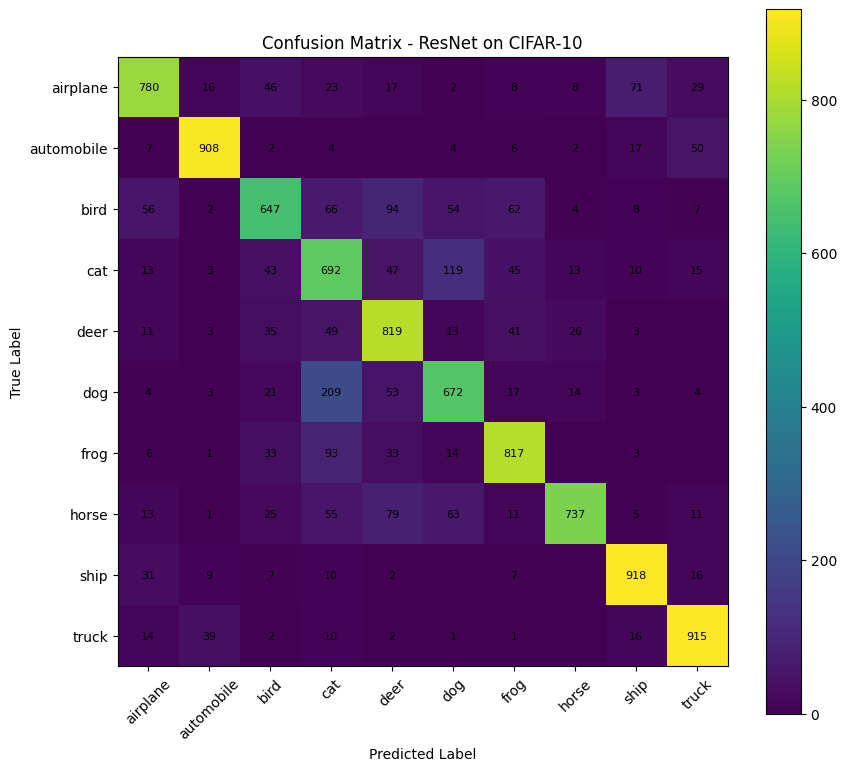

In [17]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Collecting predictions"):
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu()

        all_preds.append(preds)
        all_labels.append(labels)

    return torch.cat(all_preds), torch.cat(all_labels)

preds, labels = get_predictions(best_resnet, test_loader, device)

num_classes = len(class_names)
cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)

for true_label, pred_label in zip(labels, preds):
    cm[true_label, pred_label] += 1

plt.figure(figsize=(9, 8))
plt.imshow(cm.numpy())
plt.title("Confusion Matrix - ResNet on CIFAR-10")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)
plt.colorbar()

for i in range(num_classes):
    for j in range(num_classes):
        value = cm[i, j].item()
        if value > 0:
            plt.text(j, i, str(value), ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# Per-Class Accuracy

Overall accuracy is useful, but per-class accuracy shows which classes are easy or difficult.

In [18]:
per_class_correct = cm.diag()
per_class_total = cm.sum(dim=1)
per_class_acc = per_class_correct.float() / per_class_total.float() * 100

per_class_df = pd.DataFrame({
    "Class": class_names,
    "Accuracy (%)": per_class_acc.numpy()
}).sort_values("Accuracy (%)", ascending=False)

per_class_df

,Class,Accuracy (%)
8,ship,91.799995
9,truck,91.500000
1,automobile,90.800003
4,deer,81.900002
6,frog,81.699997
0,airplane,78.000000
7,horse,73.699997
3,cat,69.199997
5,dog,67.199997
2,bird,64.700005


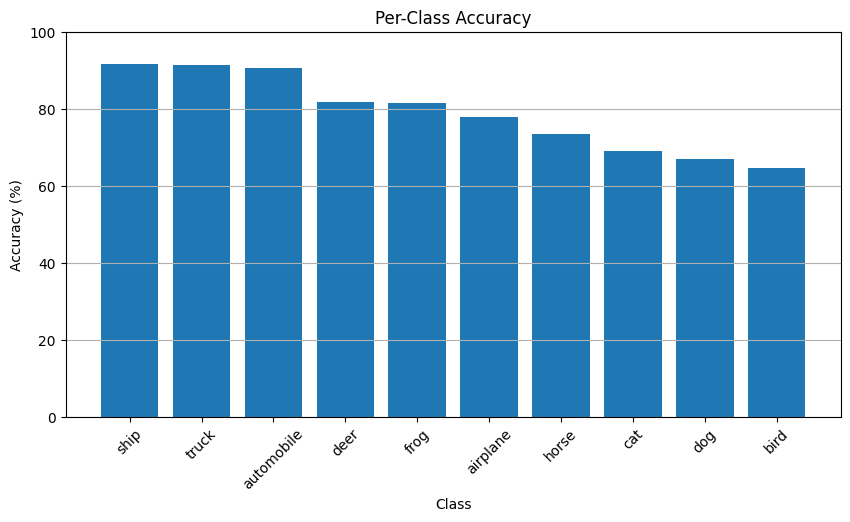

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(per_class_df["Class"], per_class_df["Accuracy (%)"])
plt.xlabel("Class")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(axis="y")
plt.show()

# Error Analysis: Show Incorrect Predictions

This section helps you understand model failures visually.

Ask:

- What classes are confused?
- Are mistakes reasonable?
- Are some images ambiguous?
- Does the model struggle with animals more than vehicles?

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


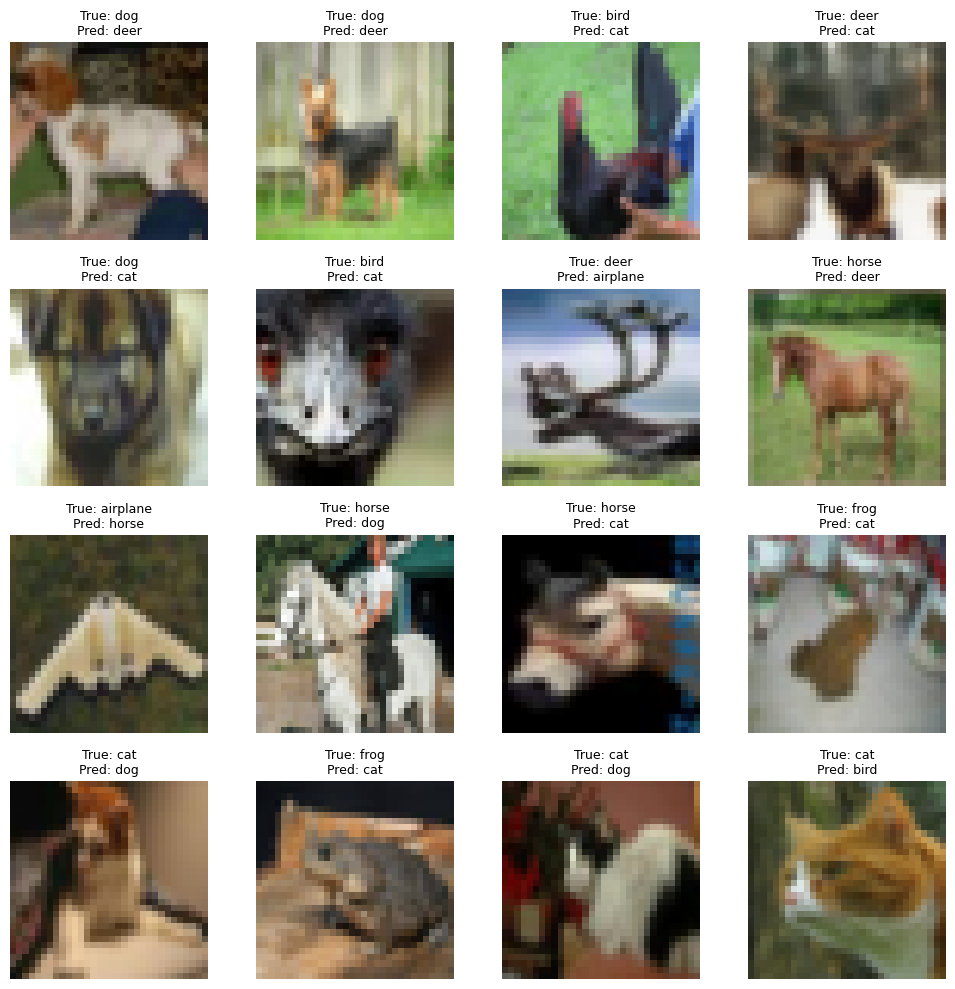

In [20]:
@torch.no_grad()
def show_incorrect_predictions(model, loader, class_names, device, max_images=16):
    model.eval()
    incorrect_images = []
    incorrect_true = []
    incorrect_pred = []

    for images, labels in loader:
        images_device = images.to(device, non_blocking=True)
        outputs = model(images_device)
        preds = torch.argmax(outputs, dim=1).cpu()

        mask = preds != labels

        for img, true_label, pred_label in zip(images[mask], labels[mask], preds[mask]):
            incorrect_images.append(img)
            incorrect_true.append(true_label.item())
            incorrect_pred.append(pred_label.item())

            if len(incorrect_images) >= max_images:
                break

        if len(incorrect_images) >= max_images:
            break

    n = len(incorrect_images)
    rows = int(np.sqrt(n))
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(cols * 2.5, rows * 2.5))

    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        img = unnormalize(incorrect_images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(
            f"True: {class_names[incorrect_true[i]]}\nPred: {class_names[incorrect_pred[i]]}",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_incorrect_predictions(best_resnet, test_loader, class_names, device, max_images=16)

# Go Beyond: Add MixUp Training

MixUp is a modern regularization technique.

Instead of training on one image and one label, MixUp blends two images and two labels.

```text
mixed_image = lambda * image_a + (1 - lambda) * image_b
mixed_label = lambda * label_a + (1 - lambda) * label_b
```

This can improve generalization.

The code below is optional. You can use it for an advanced experiment.

In [21]:
def mixup_data(x, y, alpha=1.0, device="cuda"):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a = y
    y_b = y[index]

    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("MixUp helper functions are ready.")

MixUp helper functions are ready.


# Go Beyond: Deeper ResNet Variant

To test the idea of depth, try deeper variants.

Examples:

```python
small_resnet = ResNetCIFAR10(blocks_per_stage=(1, 1, 1))
medium_resnet = ResNetCIFAR10(blocks_per_stage=(2, 2, 2))
deep_resnet = ResNetCIFAR10(blocks_per_stage=(3, 3, 3))
```

Expected result:

A deeper residual model should still train effectively because the shortcut connections improve optimization.

In [22]:
small_resnet = ResNetCIFAR10(num_classes=10, blocks_per_stage=(1, 1, 1))
medium_resnet = ResNetCIFAR10(num_classes=10, blocks_per_stage=(2, 2, 2))
deep_resnet = ResNetCIFAR10(num_classes=10, blocks_per_stage=(3, 3, 3))

depth_df = pd.DataFrame({
    "Model": ["Small ResNet", "Medium ResNet", "Deep ResNet"],
    "Blocks per Stage": ["(1, 1, 1)", "(2, 2, 2)", "(3, 3, 3)"],
    "Parameters": [
        count_parameters(small_resnet),
        count_parameters(medium_resnet),
        count_parameters(deep_resnet)
    ]
})

depth_df

,Model,Blocks per Stage,Parameters
0,Small ResNet,"(1, 1, 1)",1227594
1,Medium ResNet,"(2, 2, 2)",2777674
2,Deep ResNet,"(3, 3, 3)",4327754


# Go Beyond

Here are advanced techniques commonly followed today.

## 1. CutMix

CutMix replaces a patch from one image with a patch from another image and mixes labels.

Useful for image classification.

## 2. RandAugment

RandAugment is another strong augmentation strategy.

You can replace AutoAugment with:

```python
transforms.RandAugment()
```

## 3. AdamW

AdamW is very popular in modern deep learning.

Try:

```python
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
```

## 4. OneCycleLR

Another strong scheduler:

```python
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader)
)
```

## 5. Exponential Moving Average

EMA keeps a smoothed version of model weights.

This often improves final validation accuracy.

## 6. Test-Time Augmentation

At inference time, predict on multiple transformed versions of the same image and average predictions.

## 7. Deeper ResNet

Increase `blocks_per_stage`:

```python
ResNetCIFAR10(blocks_per_stage=(3, 3, 3))
```

## 8. Pre-activation ResNet

A later ResNet improvement moves BatchNorm and ReLU before convolution:

```text
BN → ReLU → Conv
```

This can improve very deep training.

# Final Conclusion

This notebook demonstrates the core idea of ResNet:

```text
Instead of learning H(x) directly, learn F(x) = H(x) - x and output F(x) + x.
```

The residual connection gives the network an easier optimization path.

## What we should understand now

We should be able to explain:

1. Why very deep plain networks can become hard to train.
2. Why the degradation problem is different from overfitting.
3. How a residual block works.
4. When to use identity shortcuts.
5. When to use projection shortcuts.
6. How residual learning helps deeper models train effectively.
7. How to build a modern PyTorch training pipeline.
8. How to evaluate and present the project on GitHub.
